# Poisson LDS-SVAE

This notebook is a minimal implementation of a structured VAE to recover simple latent dynamics. In particular, a 2D gaussian lds. The latent posterior is structured and computed with Kalman smoothing; the decoder and recognition network are learned by gradients; the LDS dynamics are updated with a damped M-step.

This is intended to be practice for implementing a structured VAE. 


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODULE_DIR = PROJECT_ROOT / "poisson-latent-gaussian-dynamics"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

print(sys.executable)

/Users/bennettkrentz/miniconda3/envs/structured-vae/bin/python


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from data import sample_dataset
from model import PointEstimatePoissonLDSSVAE
from train import fit_model
from viz import (
    plot_trial_diagnostics,
    plot_training_history,
    infer_posterior,
    fit_diagnostic_metrics,
    plot_latent_recovery,
    plot_transition_matrices,
    transform_dynamics_to_target_coords,
)


## 1. Simulate data

The DGP uses a 2D latent state evolving under linear Gaussian dynamics. A nonlinear network maps the latent state to Poisson firing rates.


In [3]:
key = jax.random.PRNGKey(0)

data = sample_dataset(
    key,
    num_trials = 256,
    num_timesteps = 100,
    latent_dim = 2,
    hidden_dim = 32,
    num_neurons = 30,
    dt = 0.05,
)

counts = data["counts"]
true_z = data["z"]
true_A = data["params"].A

counts.shape, true_z.shape


((256, 100, 30), (256, 100, 2))

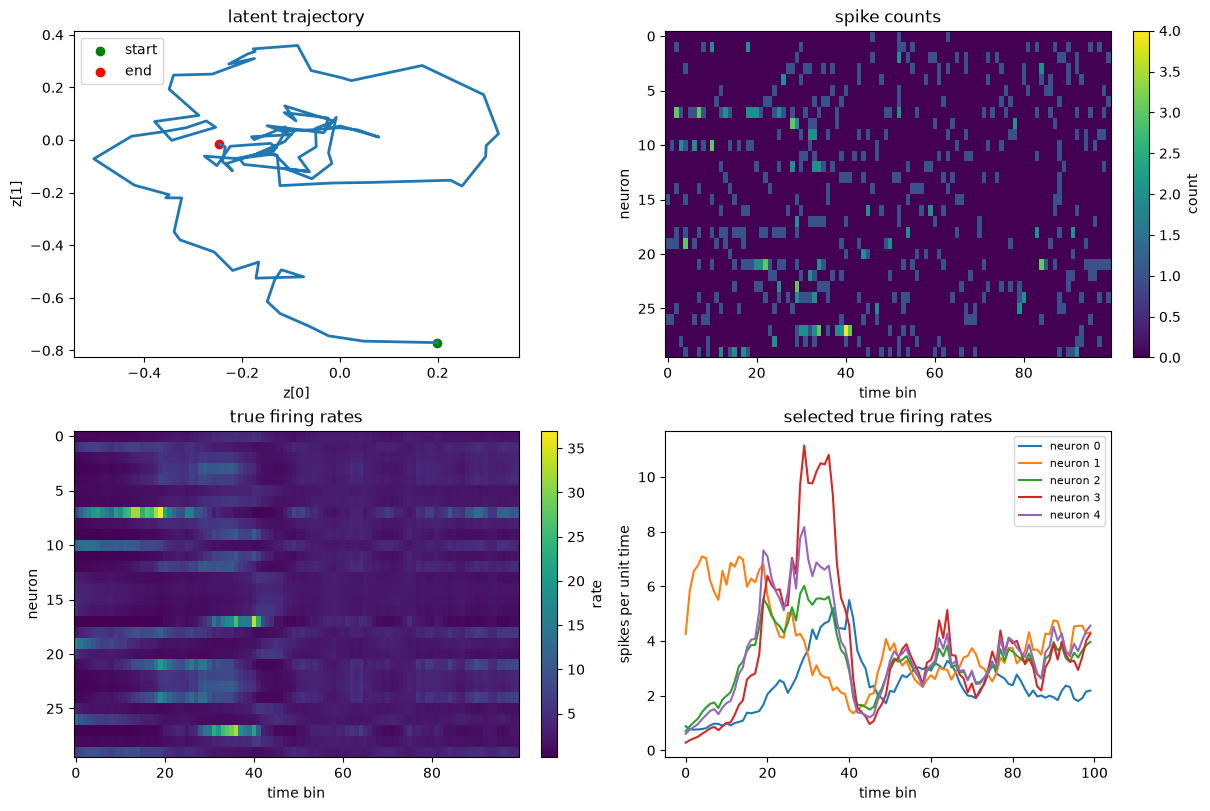

In [4]:
plot_trial_diagnostics(data, trial_idx = 0)
plt.show()


## 2. Initialise model

The fitted model uses the same 2D latent dimension as the DGP in this first reduced version. All non-latent parameters are point estimates.


In [5]:
key, init_key = jax.random.split(key)

model = PointEstimatePoissonLDSSVAE(
    latent_dim = 2,
    decoder_hidden_dim = (32, 32),
    recognition_hidden_dim = 32,
    dt = 0.05,
)

params = model.init_parameters(init_key, counts)

params.dynamics.A


Array([[0.95, 0.  ],
       [0.  , 0.95]], dtype=float32)

## 3. Train model

Each iteration recomputes the structured posterior with Kalman smoothing, updates recognition and decoder parameters by gradients, and updates the LDS dynamics from smoothed sufficient statistics.


In [6]:
import pickle

fit_path = PROJECT_ROOT / "artifacts" / "poisson_lds_svae_reduced_fit.pkl"
fit_path.parent.mkdir(exist_ok=True)
force_retrain = True

key, fit_key = jax.random.split(key)

have_current_fit = all(name in globals() for name in ("fitted_params", "state", "history"))

if fit_path.exists() and not force_retrain:
    with fit_path.open("rb") as f:
        cached_fit = pickle.load(f)

    fitted_params = cached_fit["fitted_params"]
    state = cached_fit["state"]
    history = cached_fit["history"]

    print(f"Loaded fitted model from {fit_path}")
elif have_current_fit and not force_retrain:
    with fit_path.open("wb") as f:
        pickle.dump(
            {
                "fitted_params": jax.device_get(fitted_params),
                "state": jax.device_get(state),
                "history": history,
            },
            f,
        )

    print(f"Saved current in-memory fitted model to {fit_path}")
else:
    fitted_params, state, history = fit_model(
        fit_key,
        model,
        params,
        counts,
        num_steps = 1000,
        batch_size = 16,
        learning_rate = 1e-3,
        num_samples = 1,
        dynamics_step_size = 0.05,
        log_every = 10,
        verbose = True,
    )

    with fit_path.open("wb") as f:
        pickle.dump(
            {
                "fitted_params": jax.device_get(fitted_params),
                "state": jax.device_get(state),
                "history": history,
            },
            f,
        )

    print(f"Saved fitted model to {fit_path}")


step 0000 | free_energy -1726.409 | ll -1725.293 | kl 1.116
step 0010 | free_energy -1703.800 | ll -1703.142 | kl 0.657
step 0020 | free_energy -1849.195 | ll -1848.773 | kl 0.422
step 0030 | free_energy -2106.445 | ll -2106.144 | kl 0.301
step 0040 | free_energy -1866.932 | ll -1866.680 | kl 0.252
step 0050 | free_energy -1895.712 | ll -1895.441 | kl 0.271
step 0060 | free_energy -1831.624 | ll -1831.275 | kl 0.348
step 0070 | free_energy -1655.400 | ll -1654.897 | kl 0.503
step 0080 | free_energy -1846.082 | ll -1844.110 | kl 1.971
step 0090 | free_energy -1847.942 | ll -1843.541 | kl 4.400
step 0100 | free_energy -1700.706 | ll -1696.053 | kl 4.653
step 0110 | free_energy -1646.471 | ll -1641.784 | kl 4.686
step 0120 | free_energy -1623.196 | ll -1615.680 | kl 7.516
step 0130 | free_energy -1488.729 | ll -1482.853 | kl 5.876
step 0140 | free_energy -1590.201 | ll -1579.932 | kl 10.269
step 0150 | free_energy -1573.713 | ll -1563.312 | kl 10.401
step 0160 | free_energy -1616.359 | ll

## 4. Infer posterior

After fitting, we run the recognition network and Kalman smoother on the full dataset to obtain posterior means, covariances, and cross-covariances.


In [7]:
posterior = infer_posterior(
    model,
    fitted_params,
    counts,
)

posterior.mean.shape, posterior.cov.shape, posterior.cross_cov.shape


((256, 100, 2), (256, 100, 2, 2), (256, 99, 2, 2))

## 5. Diagnose optimisation

The free energy should generally increase. The likelihood and KL terms help show which part of the objective is moving.


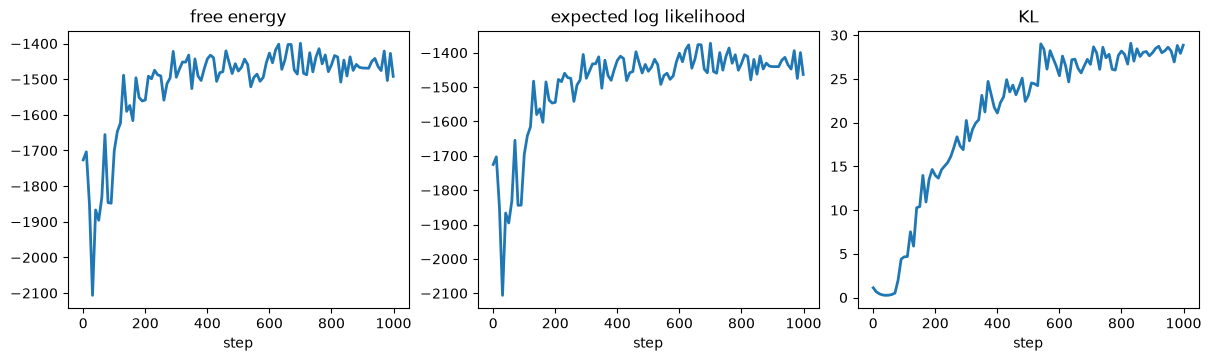

In [8]:
plot_training_history(history)
plt.show()


## 6. Diagnose latent recovery

Latent coordinates are not identifiable directly, so inferred latents are aligned to the true DGP latents before comparison.


In [9]:
metrics, alignment = fit_diagnostic_metrics(
    true_z,
    posterior.mean,
    true_A = true_A,
    learned_A = fitted_params.dynamics.A,
)

{k: float(v) for k, v in metrics.items()}


{'latent_r2': 0.8756519556045532,
 'transition_relative_error': 0.011643513105809689}

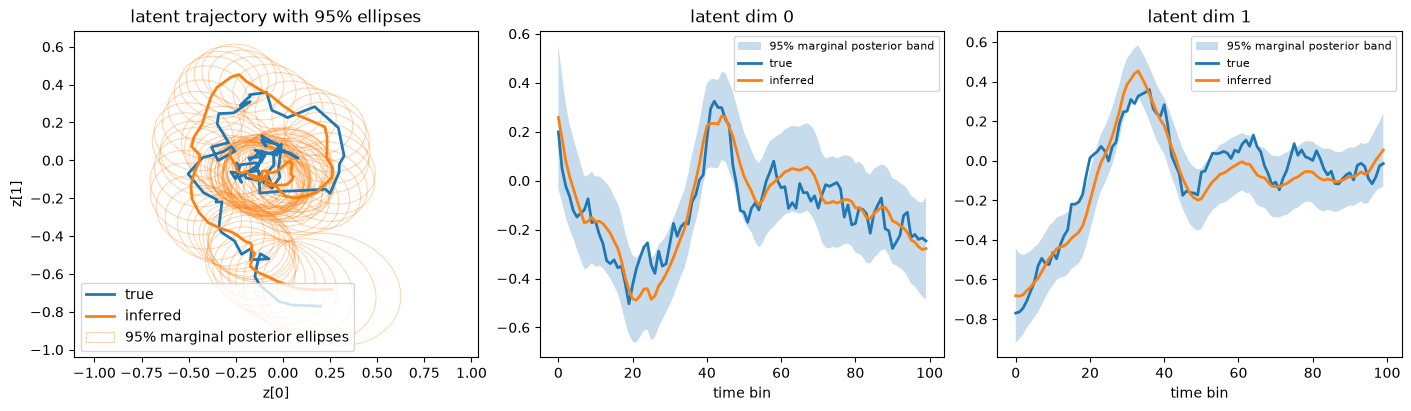

In [10]:
plot_latent_recovery(
    true_z,
    posterior.mean,
    posterior_cov = posterior.cov,
    trial_idx = 0,
    align = True,
    credible_interval = 0.95,
)
plt.show()


## 7. Diagnose dynamics recovery

The learned transition matrix should be compared after applying the same latent alignment. The raw learned matrix can look different even when the recovered dynamics are equivalent in latent space.


In [11]:
learned_A = fitted_params.dynamics.A
learned_A_aligned = transform_dynamics_to_target_coords(learned_A, alignment)

print("true A")
print(true_A)
print("learned A")
print(learned_A)
print("learned A aligned")
print(learned_A_aligned)


true A
[[ 0.94525397  0.09484175]
 [-0.09484175  0.94525397]]
learned A
[[ 0.9314638   0.11713926]
 [-0.08039764  0.9781375 ]]
learned A aligned
[[ 0.9507196   0.09814688]
 [-0.09057619  0.9588817 ]]


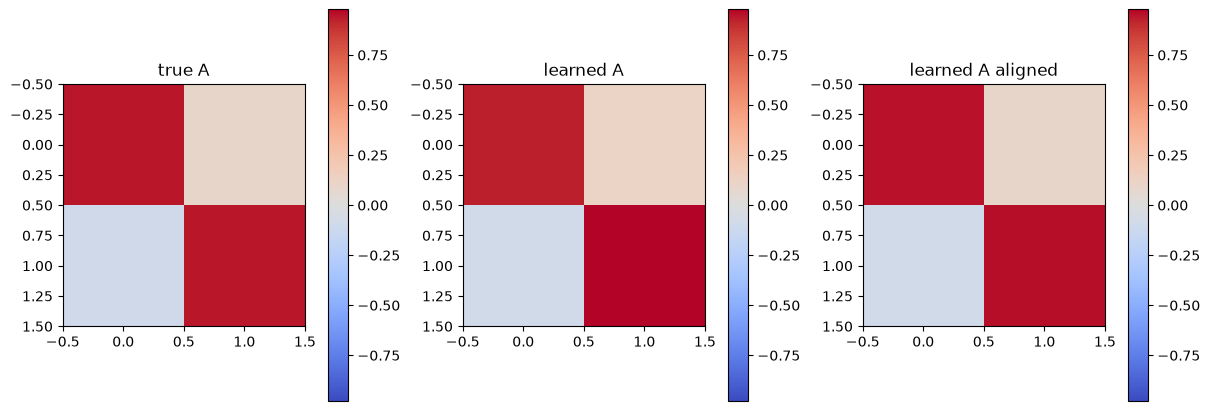

In [12]:
plot_transition_matrices(
    true_A,
    learned_A,
    alignment = alignment,
)
plt.show()
